<a href="https://colab.research.google.com/github/shaauryaa/aiml-lab-assignments/blob/main/imdailab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test  = x_test.reshape(-1, 784).astype("float32") / 255.0

y_train_oh = keras.utils.to_categorical(y_train, 10)
y_test_oh  = keras.utils.to_categorical(y_test, 10)

print(x_train.shape, x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784) (10000, 784)


In [ ]:
def build_model(units, dropout, lr):
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(units[0], activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(units[1], activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(units[2], activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

build_model((512, 256, 128), 0.2, 1e-3).summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time

results = []

def run(units, dropout, lr, epochs=5):
    model = build_model(units, dropout, lr)
    t0 = time.time()
    h = model.fit(x_train, y_train_oh, validation_split=0.1,
                  epochs=epochs, batch_size=128, verbose=0)
    results.append({"units": units, "dropout": dropout, "lr": lr,
                    "params": model.count_params(),
                    "val_acc": max(h.history["val_accuracy"]),
                    "time_s": round(time.time() - t0, 1),
                    "history": h.history})
    print(units, dropout, lr, "-> val_acc:", round(results[-1]["val_acc"], 4),
          "| params:", results[-1]["params"], "| time:", results[-1]["time_s"], "s")

for units in [(512,256,128), (256,128,64)]:
    for dropout in [0.2, 0.3]:
        for lr in [1e-3, 5e-4]:
            run(units, dropout, lr)

(512, 256, 128) 0.2 0.001 -> val_acc: 0.9822 | params: 567434 | time: 48.6 s
(512, 256, 128) 0.2 0.0005 -> val_acc: 0.9828 | params: 567434 | time: 39.2 s
(512, 256, 128) 0.3 0.001 -> val_acc: 0.9815 | params: 567434 | time: 36.9 s
(512, 256, 128) 0.3 0.0005 -> val_acc: 0.9805 | params: 567434 | time: 40.7 s
(256, 128, 64) 0.2 0.001 -> val_acc: 0.9792 | params: 242762 | time: 23.7 s
(256, 128, 64) 0.2 0.0005 -> val_acc: 0.9785 | params: 242762 | time: 22.7 s
(256, 128, 64) 0.3 0.001 -> val_acc: 0.978 | params: 242762 | time: 21.7 s
(256, 128, 64) 0.3 0.0005 -> val_acc: 0.977 | params: 242762 | time: 23.4 s


In [ ]:
np.random.seed(42)
units_opts = [(1024,512,256), (512,256,128), (256,128,64)]

for _ in range(5):
    run(units_opts[np.random.randint(3)],
        np.random.choice([0.0, 0.2, 0.3, 0.4]),
        np.random.choice([3e-3, 1e-3, 5e-4, 1e-4]))

(256, 128, 64) 0.4 0.003 -> val_acc: 0.9758 | params: 242762 | time: 25.7 s
(256, 128, 64) 0.3 0.0001 -> val_acc: 0.9582 | params: 242762 | time: 22.9 s
(1024, 512, 256) 0.0 0.0005 -> val_acc: 0.9818 | params: 1462538 | time: 74.9 s
(512, 256, 128) 0.3 0.0005 -> val_acc: 0.9798 | params: 567434 | time: 37.4 s
(256, 128, 64) 0.3 0.0001 -> val_acc: 0.9562 | params: 242762 | time: 24.2 s


In [ ]:
best = max(results, key=lambda r: r["val_acc"])
best_units, best_dropout, best_lr = best["units"], best["dropout"], best["lr"]
print("Best config:", best_units, best_dropout, best_lr)

model = build_model(best_units, best_dropout, best_lr)
history = model.fit(x_train, y_train_oh, validation_split=0.1,
                    epochs=20, batch_size=128, verbose=2)

test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
print("Test accuracy:", round(test_acc, 4), "| Test loss:", round(test_loss, 4))

Best config: (512, 256, 128) 0.2 0.0005
Epoch 1/20
422/422 - 10s - 24ms/step - accuracy: 0.8782 - loss: 0.3992 - val_accuracy: 0.9652 - val_loss: 0.1195
Epoch 2/20
422/422 - 9s - 21ms/step - accuracy: 0.9563 - loss: 0.1495 - val_accuracy: 0.9758 - val_loss: 0.0867
Epoch 3/20
422/422 - 8s - 18ms/step - accuracy: 0.9682 - loss: 0.1045 - val_accuracy: 0.9782 - val_loss: 0.0699
Epoch 4/20
422/422 - 6s - 15ms/step - accuracy: 0.9760 - loss: 0.0784 - val_accuracy: 0.9810 - val_loss: 0.0649
Epoch 5/20
422/422 - 7s - 18ms/step - accuracy: 0.9810 - loss: 0.0622 - val_accuracy: 0.9808 - val_loss: 0.0602
Epoch 6/20
422/422 - 10s - 23ms/step - accuracy: 0.9830 - loss: 0.0529 - val_accuracy: 0.9817 - val_loss: 0.0635
Epoch 7/20
422/422 - 7s - 17ms/step - accuracy: 0.9866 - loss: 0.0434 - val_accuracy: 0.9820 - val_loss: 0.0602
Epoch 8/20
422/422 - 7s - 18ms/step - accuracy: 0.9885 - loss: 0.0362 - val_accuracy: 0.9822 - val_loss: 0.0639
Epoch 9/20
422/422 - 9s - 21ms/step - accuracy: 0.9897 - loss:

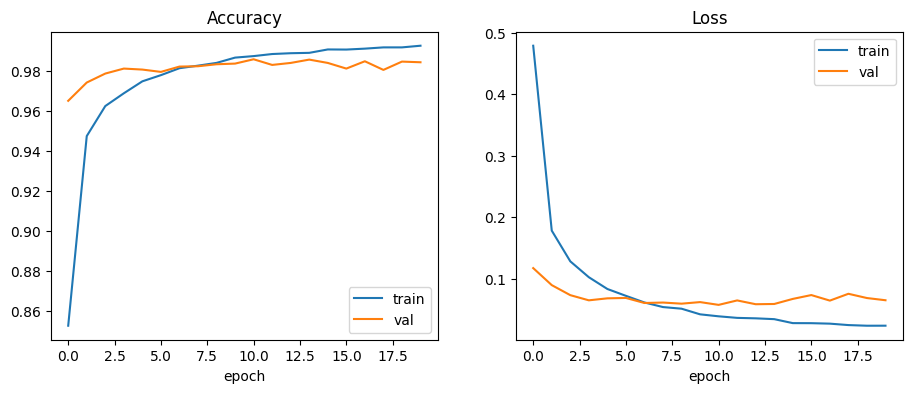

In [ ]:
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.xlabel("epoch"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.xlabel("epoch"); plt.legend()

plt.show()

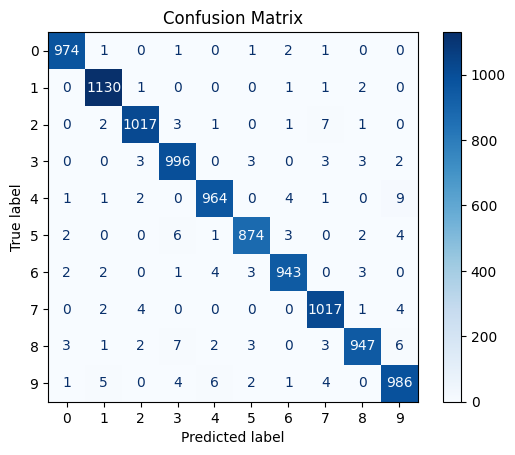

Architecture   : 784-512-256-128-10
Dropout        : 0.3
Learning rate  : 0.0005
Parameters     : 567434
Test accuracy  : 0.9848
Test loss      : 0.0658


In [ ]:
y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix"); plt.show()

print("Architecture   :", "784-" + "-".join(map(str, best_units)) + "-10")
print("Dropout        :", best_dropout)
print("Learning rate  :", best_lr)
print("Parameters     :", model.count_params())
print("Test accuracy  :", round(test_acc, 4))
print("Test loss      :", round(test_loss, 4))

In [ ]:
import pandas as pd

df = pd.DataFrame([{k: v for k, v in r.items() if k != "history"} for r in results])
df = df.sort_values("val_acc", ascending=False)
df

,units,dropout,lr,params,val_acc,time_s
1,"(512, 256, 128)",0.2,0.0005,567434,0.982833,39.2
0,"(512, 256, 128)",0.2,0.0010,567434,0.982167,48.6
10,"(1024, 512, 256)",0.0,0.0005,1462538,0.981833,74.9
2,"(512, 256, 128)",0.3,0.0010,567434,0.981500,36.9
3,"(512, 256, 128)",0.3,0.0005,567434,0.980500,40.7
11,"(512, 256, 128)",0.3,0.0005,567434,0.979833,37.4
4,"(256, 128, 64)",0.2,0.0010,242762,0.979167,23.7
5,"(256, 128, 64)",0.2,0.0005,242762,0.978500,22.7
6,"(256, 128, 64)",0.3,0.0010,242762,0.978000,21.7
7,"(256, 128, 64)",0.3,0.0005,242762,0.977000,23.4
